# 🐾 Animal Detection & Alert System
**YOLOv8 + EfficientNet | Danger Level Classification**

This notebook demonstrates the full pipeline of the Animal Detection & Alert System:
- Load YOLOv8 model
- Detect animals in images
- Classify danger levels (HIGH / MEDIUM / LOW)
- Visualize results with bounding boxes

> 🚀 For the full interactive web app, run `streamlit run app.py`

## 📦 Step 1 — Install Dependencies

In [1]:
# Run this cell only once
!pip install ultralytics opencv-python-headless Pillow numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.7 MB/s eta 0:00:00


## 🔧 Step 2 — Import Libraries & Define Danger Map

In [2]:
import cv2
import numpy as np
from PIL import Image
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Danger classification map
DANGER_MAP = {
    'dog': 'LOW',    'cat': 'LOW',    'sheep': 'LOW',
    'bird': 'LOW',   'giraffe': 'LOW',
    'cow': 'MEDIUM', 'horse': 'MEDIUM', 'zebra': 'MEDIUM',
    'elephant': 'HIGH', 'bear': 'HIGH',
    'lion': 'HIGH',  'tiger': 'HIGH',
}

DANGER_COLORS = {
    'HIGH':   (0, 0, 255),
    'MEDIUM': (0, 165, 255),
    'LOW':    (0, 255, 0),
}

DANGER_EMOJI = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}

print('✅ Libraries loaded successfully!')
print(f'📋 Tracking {len(DANGER_MAP)} animal classes')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries loaded successfully!
📋 Tracking 12 animal classes


## 🤖 Step 3 — Load YOLOv8 Model

In [3]:
# Load YOLOv8 nano model (downloads automatically ~6MB)
model = YOLO('yolov8n.pt')

print('✅ YOLOv8n model loaded!')
print(f'📊 Total classes available: {len(model.names)}')

# Show which dangerous animals are in COCO dataset
tracked = {k: v for k, v in model.names.items() if v in DANGER_MAP}
print(f'\n🐾 Animals we track ({len(tracked)}):')
for idx, name in tracked.items():
    print(f'   [{idx:3d}] {name:12s} → {DANGER_EMOJI[DANGER_MAP[name]]} {DANGER_MAP[name]}')

✅ YOLOv8n model loaded!
📊 Total classes available: 80

🐾 Animals we track (10):
   [ 14] bird         → 🟢 LOW
   [ 15] cat          → 🟢 LOW
   [ 16] dog          → 🟢 LOW
   [ 17] horse        → 🟡 MEDIUM
   [ 18] sheep        → 🟢 LOW
   [ 19] cow          → 🟡 MEDIUM
   [ 20] elephant     → 🔴 HIGH
   [ 21] bear         → 🔴 HIGH
   [ 22] zebra        → 🟡 MEDIUM
   [ 23] giraffe      → 🟢 LOW


## 🔍 Step 4 — Detection Function

In [4]:
def detect_and_classify(image_path, conf=0.5, show=True):
    """
    Run YOLOv8 detection + danger classification on an image.

    Args:
        image_path: path to image file
        conf: confidence threshold (0.0 - 1.0)
        show: display result inline

    Returns:
        detections list, highest danger level
    """
    # Load image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f'❌ Could not load image: {image_path}')
        return [], 'NONE'

    # Run YOLO detection
    results = model(img_bgr, conf=conf, verbose=False)
    annotated = results[0].plot()

    detections = []
    for r in results:
        for box in r.boxes:
            cls_id     = int(box.cls[0])
            label      = model.names[cls_id]
            confidence = float(box.conf[0])
            danger     = DANGER_MAP.get(label, 'LOW')
            x1,y1,x2,y2 = [int(v) for v in box.xyxy[0]]

            # Add danger label on frame
            color  = DANGER_COLORS[danger]
            text_y = max(y1 - 30, 20)
            cv2.putText(annotated, f'Danger: {danger}',
                        (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, color, 2)

            detections.append({
                'label': label,
                'confidence': round(confidence, 3),
                'danger': danger,
                'bbox': (x1, y1, x2, y2)
            })

    # Get highest danger
    priority = {'HIGH': 3, 'MEDIUM': 2, 'LOW': 1}
    highest  = max(detections, key=lambda d: priority[d['danger']])['danger'] \
               if detections else 'NONE'

    # Display result
    if show:
        rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(rgb)
        plt.axis('off')
        alert_color = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green', 'NONE': 'gray'}
        plt.title(f'Detection Result — Alert: {highest}',
                  color=alert_color.get(highest, 'gray'), fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Print summary
    print(f'\n📊 Detection Summary for: {image_path}')
    print(f'   Total detections : {len(detections)}')
    print(f'   Highest danger   : {DANGER_EMOJI.get(highest, "⚫")} {highest}')
    print()
    for d in detections:
        print(f'   {DANGER_EMOJI[d["danger"]]} {d["label"]:12s} | '
              f'conf: {d["confidence"]:.3f} | danger: {d["danger"]}')

    return detections, highest

print('✅ Detection function ready!')

✅ Detection function ready!


## 🖼️ Step 5 — Test on Sample Images

Download sample animal images for testing:

In [11]:
import os, urllib.request

os.makedirs('sample_images', exist_ok=True)

# Download free sample images (Wikimedia Commons — public domain)
samples = {
    'sample_images/elephant.jpg': 'https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg',
    'sample_images/dog.jpg':      'https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg',
    'sample_images/horse.jpg':    'https://upload.wikimedia.org/wikipedia/commons/d/de/Nokota_Horses_cropped.jpg',
}

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

for path, url in samples.items():
    if not os.path.exists(path):
        req = urllib.request.Request(url, headers=headers)
        with (
            urllib.request.urlopen(req) as response,
            open(path, 'wb') as out_file
        ):
            out_file.write(response.read())
        print(f'✅ Downloaded: {path}')
    else:
        print(f'✓  Already exists: {path}')

print('\n🖼️  Sample images ready!')

✅ Downloaded: sample_images/elephant.jpg
✅ Downloaded: sample_images/dog.jpg
✅ Downloaded: sample_images/horse.jpg

🖼️  Sample images ready!


### Test 1 — HIGH Danger (Elephant)

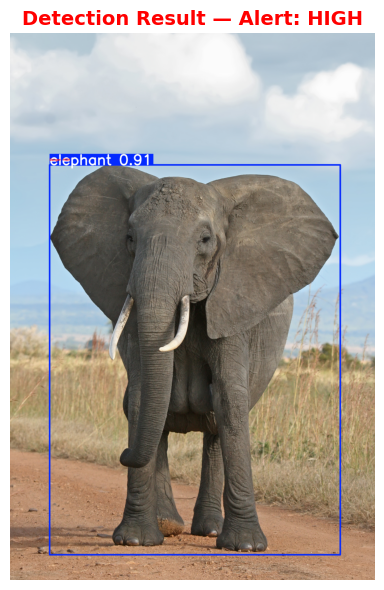


📊 Detection Summary for: sample_images/elephant.jpg
   Total detections : 1
   Highest danger   : 🔴 HIGH

   🔴 elephant     | conf: 0.913 | danger: HIGH


In [12]:
dets, highest = detect_and_classify('sample_images/elephant.jpg', conf=0.3)

### Test 2 — LOW Danger (Dog)

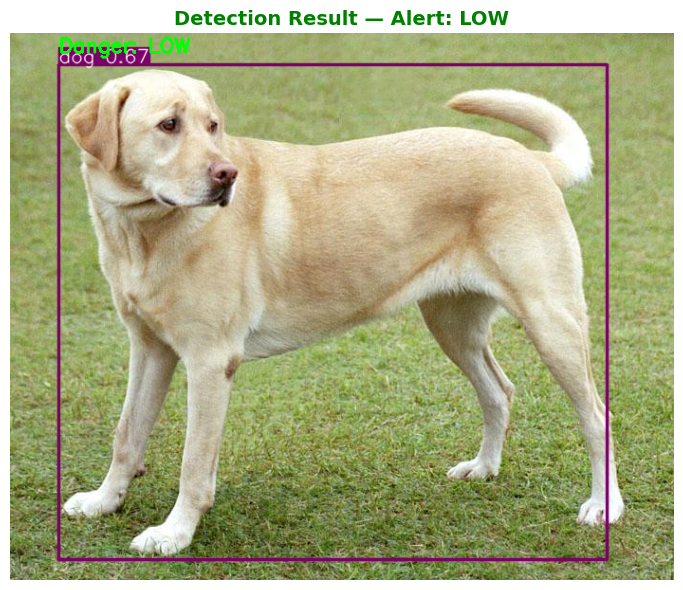


📊 Detection Summary for: sample_images/dog.jpg
   Total detections : 1
   Highest danger   : 🟢 LOW

   🟢 dog          | conf: 0.666 | danger: LOW


In [13]:
dets, highest = detect_and_classify('sample_images/dog.jpg', conf=0.3)

### Test 3 — MEDIUM Danger (Horse)

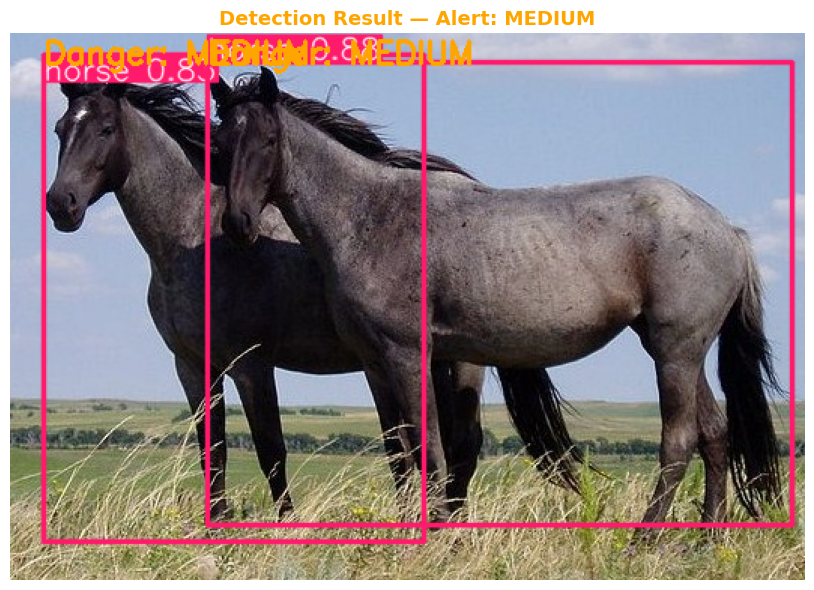


📊 Detection Summary for: sample_images/horse.jpg
   Total detections : 2
   Highest danger   : 🟡 MEDIUM

   🟡 horse        | conf: 0.882 | danger: MEDIUM
   🟡 horse        | conf: 0.830 | danger: MEDIUM


In [14]:
dets, highest = detect_and_classify('sample_images/horse.jpg', conf=0.3)

## 📊 Step 6 — Confidence Threshold Comparison

In [15]:
# Show how confidence threshold affects detections
print('🔬 Confidence Threshold Analysis\n')
print(f'{"Threshold":>12} | {"Detections":>12} | {"Highest Danger"}')
print('-' * 45)

for conf_val in [0.3, 0.5, 0.7, 0.9]:
    results_tmp = model('sample_images/elephant.jpg', conf=conf_val, verbose=False)
    n = len(results_tmp[0].boxes)
    dets_tmp = [model.names[int(b.cls[0])] for b in results_tmp[0].boxes]
    dangers  = [DANGER_MAP.get(d, 'LOW') for d in dets_tmp]
    priority = {'HIGH': 3, 'MEDIUM': 2, 'LOW': 1}
    top = max(dangers, key=lambda x: priority[x]) if dangers else 'NONE'
    print(f'{conf_val:>12.1f} | {n:>12} | {DANGER_EMOJI.get(top, "⚫")} {top}')

🔬 Confidence Threshold Analysis

   Threshold |   Detections | Highest Danger
---------------------------------------------
         0.3 |            1 | 🔴 HIGH
         0.5 |            1 | 🔴 HIGH
         0.7 |            1 | 🔴 HIGH
         0.9 |            1 | 🔴 HIGH
